# ArXiv Dataset Exploration

## Notebook Imports

In [108]:
from datasets import load_dataset, load_from_disk
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import numpy as np
import pandas as pd

from arxiv_paper_discovery.config import BASE_DATA_PATH, PROCESSED_DATA_DIR
from arxiv_paper_discovery.utils import compute_label_coverage

## Raw Dataset

In [27]:
raw_dataset_json = load_dataset(
    "json",
    data_files="../data/raw/arxiv/arxiv-metadata-oai-snapshot.json",
    split="train",
)

print(f"No of samples: {len(raw_dataset_json)}")
print(f"Columns : {raw_dataset_json.column_names}")

No of samples: 2982054
Columns : ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed']


## Base Dataset

In [61]:
base_dataset = load_from_disk(BASE_DATA_PATH)

print(base_dataset)
print(f"Sample: {base_dataset[0]}")

Dataset({
    features: ['id', 'title', 'abstract', 'categories', 'authors', 'update_date'],
    num_rows: 2982054
})
Sample: {'id': '0704.0001', 'title': 'Calculation of prompt diphoton production cross sections at Tevatron and LHC energies', 'abstract': 'A fully differential calculation in perturbative quantum chromodynamics is presented for the production of massive photon pairs at hadron colliders. All next-to-leading order perturbative contributions from quark-antiquark, gluon-(anti)quark, and gluon-gluon subprocesses are included, as well as all-orders resummation of initial-state gluon radiation valid at next-to-next-to-leading logarithmic accuracy. The region of phase space is specified in which the calculation is most reliable. Good agreement is demonstrated with data from the Fermilab Tevatron, and predictions are made for more detailed tests with CDF and DO data. Predictions are shown for distributions of diphoton pairs produced at the energy of the Large Hadron Collider (LH

### Label Distribution

In [109]:
from collections import Counter
import pandas as pd
from tqdm import tqdm

counter = Counter()

for labels in tqdm(base_dataset["categories"], desc="Counting labels"):
    counter.update(labels)

label_df = pd.DataFrame(counter.items(), columns=["label", "count"])
label_df = label_df.sort_values(by="count", ascending=False).reset_index(drop=True)
label_df.to_csv("../outputs/analysis/label_distribution.csv", index=False)

label_df.head()

In [133]:
# Top 10 and bottom 10 labels
top10 = label_df.head(10).reset_index(drop=True)
bottom10 = label_df.tail(10).reset_index(drop=True)
side_by_side = pd.concat([top10, bottom10], axis=1, keys=["Top 10", "Bottom 10"])
side_by_side

Top 10         Bottom 10      
               label   count     label count
0              cs.LG  257067   mtrl-th   262
1             hep-ph  194395   chem-ph   251
2              cs.CV  184612     cs.GL   229
3             hep-th  180625  comp-gas   221
4           quant-ph  175671  supr-con   175
5              cs.AI  166910   atom-ph   123
6              gr-qc  120089  acc-phys    49
7  cond-mat.mtrl-sci  107107  plasm-ph    38
8           astro-ph  105380    ao-sci    17
9              cs.CL  104104  bayes-an    16

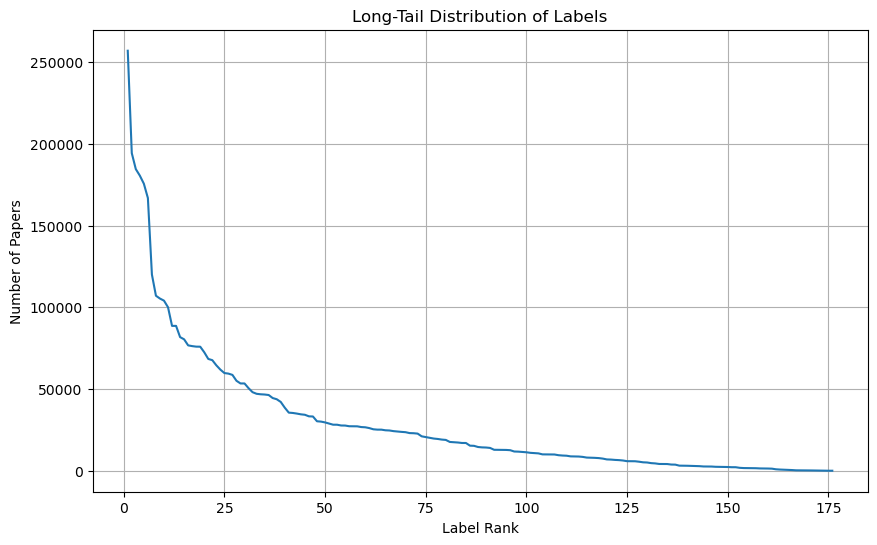

In [134]:
# Plotting the long-tail distribution

counts = label_df["count"].values

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(counts)+1), counts)
plt.xlabel("Label Rank")
plt.ylabel("Number of Papers")
plt.title("Long-Tail Distribution of Labels")
plt.grid()

plt.savefig("../outputs/plots/long_tail.png", dpi=300)
plt.show()

### Stats for categories per paper

In [131]:
from tqdm import tqdm
import numpy as np

num_categories_per_paper = [
    len(item["categories"]) 
    for item in tqdm(base_dataset, desc="Counting categories per paper")
]

print("\nStats for categories per paper:")
print(f"Average: {np.mean(num_categories_per_paper):.2f}")
print(f"Max: {np.max(num_categories_per_paper)}")
print(f"Min: {np.min(num_categories_per_paper)}")

Counting categories per paper: 100%|██████████| 2982054/2982054 [01:37<00:00, 30679.93it/s]



Stats for categories per paper:
Average: 1.72
Max: 13
Min: 1


### % of papers covered by top k labels

In [41]:
coverage, labels = compute_label_coverage(base_dataset)

Computing coverage: 100%|██████████| 176/176 [00:22<00:00,  7.79it/s]


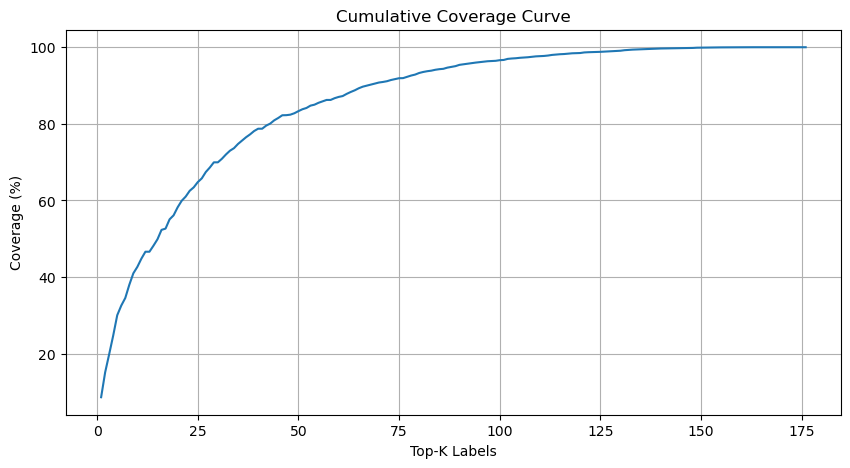

In [135]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(coverage)+1), coverage)
plt.xlabel("Top-K Labels")
plt.ylabel("Coverage (%)")
plt.title("Cumulative Coverage Curve")
plt.grid()
plt.savefig("../outputs/plots/cumulative_coverage_curve.png", dpi=300)
plt.show()

### Labels

## Processed Dataset

In [148]:
arxiv_taxonomy_dataset = load_from_disk(PROCESSED_DATA_DIR / "arxiv_taxonomy_dataset")
print(arxiv_taxonomy_dataset)
print(arxiv_taxonomy_dataset['train'][0])

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'abstract', 'categories', 'authors', 'update_date', 'labels'],
        num_rows: 2385643
    })
    val: Dataset({
        features: ['id', 'title', 'abstract', 'categories', 'authors', 'update_date', 'labels'],
        num_rows: 298205
    })
    test: Dataset({
        features: ['id', 'title', 'abstract', 'categories', 'authors', 'update_date', 'labels'],
        num_rows: 298206
    })
})
{'id': 'gr-qc/0609104', 'title': 'Duality invariance and cosmological dynamics', 'abstract': 'A duality transformation that interrelates expanding and contracting cosmological models is shown to single out a duality invariant, interacting two-component description of any irrotational, geodesic and shearfree cosmic medium with vanishing three curvature scalar. We apply this feature to a system of matter and radiation, to a mixture of dark matter and dark energy, to minimal and conformal scalar fields, and to an enlarged Chaplygin 

In [149]:
import json

with open(PROCESSED_DATA_DIR / "group_to_index.json") as f:
    group_to_index = json.load(f)

index_to_group = {v: k for k, v in group_to_index.items()}

In [153]:
labels = arxiv_taxonomy_dataset["train"][1]["labels"]

decoded = [index_to_group[i] for i, v in enumerate(labels) if v == 1]
print(decoded)

['Astrophysics']


In [156]:
from collections import Counter

label_counts = Counter()

for row in arxiv_taxonomy_dataset["train"]:
    for i, v in enumerate(row["labels"]):
        if v == 1:
            label_counts[index_to_group[i]] += 1
label_counts

Counter({'Pure Mathematics': 397615,
         'Condensed Matter Physics': 330785,
         'High Energy Physics': 307496,
         'Astrophysics': 304267,
         'Machine Learning': 295509,
         'Physics Other': 268455,
         'CS Theory and Algorithms': 160987,
         'Systems and Control': 157161,
         'Computer Vision': 147418,
         'Quantum Physics': 140570,
         'Statistics and Probability': 110015,
         'Gravitational Physics': 96000,
         'Human Computer Interaction': 95133,
         'Natural Language Processing': 83263,
         'Optimization and Numerical Methods': 82524,
         'Mathematical Physics': 71015,
         'Nuclear Physics': 61906,
         'Quantitative Biology': 43195,
         'Information Theory': 42717,
         'Robotics': 40427,
         'Security and Cryptography': 37092,
         'Quantitative Finance and Economics': 25963,
         'Computer Science Other': 2203})

In [157]:
# Average number of labels per paper
total_labels = sum(sum(row["labels"]) for row in arxiv_taxonomy_dataset["train"])
num_papers = len(arxiv_taxonomy_dataset["train"])

avg_labels = total_labels / num_papers
print(avg_labels)

1.3839941684485064
